# LSTM Autoencoder for ECG Anomaly Detection

This notebook introduces the first deep reconstruction model in the project.

The progression is:

- **ARMA** models local temporal dependencies with a classical linear time-series model.
- **PCA** reconstructs each beat with a linear low-dimensional representation.
- **LSTM Autoencoder** reconstructs each beat as an ordered sequence, allowing nonlinear temporal patterns.

The anomaly score is still the reconstruction error. This keeps the evaluation logic comparable with ARMA and PCA.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    read_record_names,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import LSTMAutoencoderAnomalyDetector

## Load Records

We keep the same 5-record subset used for ARMA and PCA. This makes the first comparison easier and keeps training time controlled.

In [ ]:
N_RECORDS = 5

# Paced records are excluded via config.DROP_PACED (see read_record_names).
record_names = read_record_names(config.MIT_BIH_PATH)[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

## Create Beat Dataset

Each row is one beat window of 180 samples. The label belongs to the whole beat segment.

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10634, 7)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     6440
anomaly    4194
Name: count, dtype: int64

symbol
N    6440
/    3407
f     722
A      38
Q      20
V       7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10634, 180)
y shape: (10634,)


## Train/Test Split by Record

The split is performed by record to reduce leakage between train and test beats.

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '102', '103']
Test records: ['104']
Train shape: (8406, 180)
Test shape: (2228, 180)
Train labels:


normal     6277
anomaly    2129
Name: count, dtype: int64

Test labels:


anomaly    2065
normal      163
Name: count, dtype: int64

## Fit LSTM Autoencoder

The model is trained only on normal training beats. This follows a semi-supervised anomaly detection setup: the autoencoder learns to reconstruct normal morphology, and anomalous beats should produce larger reconstruction errors.

For this first experiment we use a limited number of normal training beats to keep runtime manageable.

In [6]:
MAX_TRAIN_NORMAL = 1000
MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

X_train_normal = split["X_train"][split["y_train"] == 0]
rng.shuffle(X_train_normal)
X_train_normal = X_train_normal[:MAX_TRAIN_NORMAL]

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_eval = split["X_test"][test_indices]
y_test_eval = split["y_test"][test_indices]

print("Normal training beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_eval))
display(pd.Series(y_test_eval).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("PyTorch device:", "cuda" if torch.cuda.is_available() else "cpu")

Normal training beats used: 1000
Test beats used: 300


normal     150
anomaly    150
Name: count, dtype: int64

PyTorch device: cuda


In [7]:
lstm_ae = LSTMAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN,
    hidden_size=16,
    latent_dim=8,
    threshold_percentile=95,
    learning_rate=1e-3,
    batch_size=64,
    epochs=10,
    random_state=config.RANDOM_SEED,
)

lstm_ae.fit(X_train_normal)

print("Threshold:", lstm_ae.threshold)
print("Final training loss:", lstm_ae.history[-1])

Threshold: 0.029879665467888113
Final training loss: 0.026007882202975452


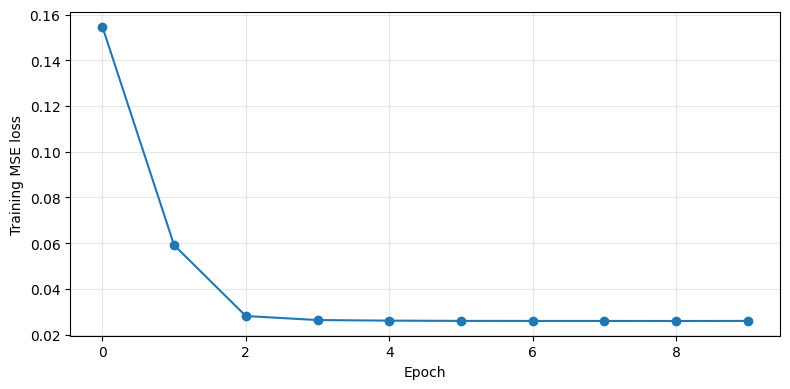

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_ae.history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training MSE loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate

In [9]:
scores = lstm_ae.anomaly_score(X_test_eval)
y_pred = lstm_ae.predict(X_test_eval)

results = evaluate_anomaly_detection(y_test_eval, y_pred, scores)
results

{'confusion_matrix': [[0, 150], [21, 129]],
 'precision': 0.46236559139784944,
 'recall': 0.86,
 'f1': 0.6013986013986014,
 'roc_auc': 0.6206222222222223,
 'pr_auc': 0.7266441359482902}

### Metric Interpretation

With the default 95th percentile threshold, the LSTM Autoencoder obtains high recall but low precision. This means that it detects many anomalous beats, but it also marks many normal beats as anomalous.

In this preliminary run, the ROC-AUC and PR-AUC are lower than PCA. This suggests that the current LSTM setup has not yet learned a reconstruction score that separates normal and anomalous beats as clearly as the linear PCA baseline. This is not necessarily a failure of the model class: it may depend on architecture size, number of epochs, training subset, threshold choice, or record-level distribution shift.

## Threshold Sensitivity

As with ARMA and PCA, the threshold converts reconstruction scores into binary predictions. We inspect several percentiles instead of assuming that the default 95th percentile is always appropriate.

In [10]:
threshold_results = []
train_scores = lstm_ae.anomaly_score(X_train_normal)

for percentile in [95, 97, 98, 99, 99.5, 99.9]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_eval, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95.0,0.029880,0.462366,0.860000,0.601399,0.620622,0.726644
1,97.0,0.030855,0.456522,0.840000,0.591549,0.620622,0.726644
2,98.0,0.031994,0.452555,0.826667,0.584906,0.620622,0.726644
3,99.0,0.060165,0.925926,0.166667,0.282486,0.620622,0.726644
4,99.5,0.064310,0.875000,0.093333,0.168675,0.620622,0.726644
5,99.9,0.085676,1.000000,0.033333,0.064516,0.620622,0.726644


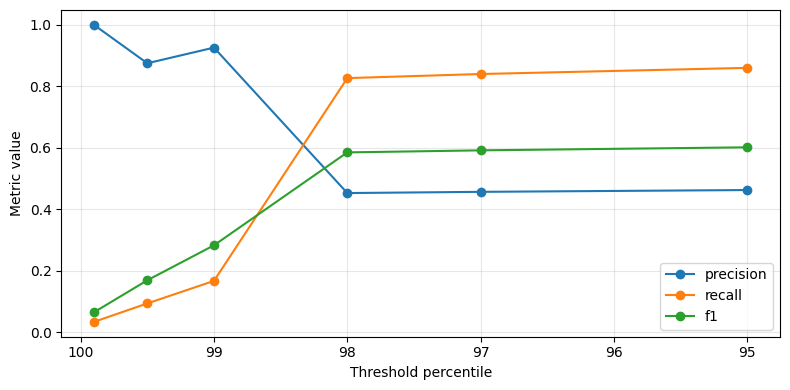

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

The threshold sensitivity table shows a clear trade-off. Lower thresholds keep recall high but produce many false positives; very high thresholds increase precision but miss most anomalies.

For example, the 99th percentile greatly increases precision but drops recall sharply. This behavior is useful for discussion because it shows that the operating point must be selected according to the cost of false positives and false negatives.

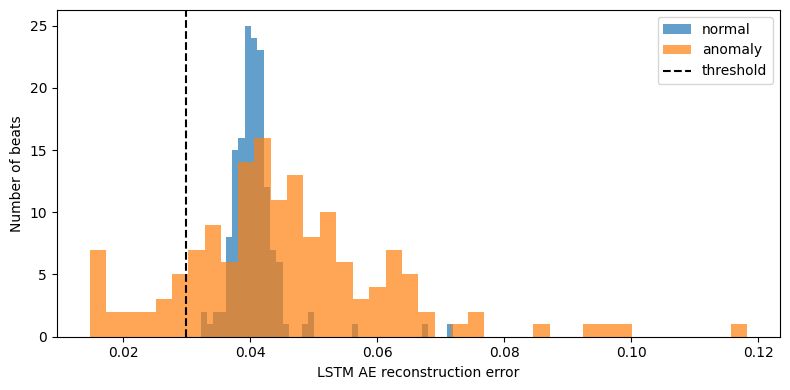

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_eval == 0], bins=40, alpha=0.7, label="normal")
plt.hist(scores[y_test_eval == 1], bins=40, alpha=0.7, label="anomaly")
plt.axvline(lstm_ae.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("LSTM AE reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

- LSTM AE is the first nonlinear sequential reconstruction model in the project.
- The input beat is treated as an ordered sequence of 180 samples.
- The model is trained on normal beats and evaluated by reconstruction error.
- In this first controlled experiment it does not outperform PCA, which is an important result rather than something to hide.
- A more complex model is not automatically better: it needs enough data, appropriate capacity, and stable training.
- The next step is to either tune the LSTM setup or move to VAE as a probabilistic reconstruction model, then compare again under the same protocol.